In [3]:
import numpy as np
from numpy.linalg import eigh, eig
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import time

In [122]:
start = time.time()

# =========================
# PARAMETERS
# =========================
Nk = 21
Nk_tot = Nk * Nk
Nc = 8

T = 0.04

t = 1.0
ta_p = -0.3
tb_p = 0.2
mu = 0.75
lam_soc = 0.0
J = 0.93 #2.0/3

# =========================
# PAULI MATRICES
# =========================
tau0 = np.eye(2)
tau1 = np.array([[0,1],[1,0]])
tau2 = np.array([[0,-1j],[1j,0]])
tau3 = np.array([[1,0],[0,-1]])

sigma0 = np.eye(2)
sigma1 = np.array([[0,1],[1,0]])
sigma2 = np.array([[0,-1j],[1j,0]])
sigma3 = np.array([[1,0],[0,-1]])

# =========================
# 16 Γ MATRICES (keep full set)
# =========================
Gammas_all = [
    np.kron(tau0, sigma0), np.kron(tau3, sigma3),
    np.kron(tau3, sigma0), np.kron(tau0, sigma3),
    np.kron(tau1, sigma2), np.kron(tau2, sigma1),
    np.kron(tau1, sigma1), np.kron(tau2, sigma2),
    np.kron(tau2, sigma0), np.kron(tau2, sigma3),
    np.kron(tau1, sigma0), np.kron(tau1, sigma3),
    np.kron(tau0, sigma1), np.kron(tau0, sigma2),
    np.kron(tau3, sigma1), np.kron(tau3, sigma2)
]

# only first 8 channels used in pairing space
Gammas = Gammas_all[:Nc]

# =========================
# k GRID
# =========================
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
k_points = np.array([(kx, ky) for kx in kx_list for ky in ky_list])

# =========================
# HAMILTONIAN
# =========================
# def H0(kx, ky, t, lam):

#     h0 = -(ta_p + tb_p)*(np.cos(kx)+np.cos(ky)) - mu
#     h1 = -4*t*np.cos(kx/2)*np.cos(ky/2)
#     h3 = -(ta_p - tb_p)*(np.cos(kx)-np.cos(ky))
#     h2 = lam * np.sin(kx/2)*np.sin(ky/2)

#     H = (
#         h0*Gammas_all[0] +
#         h1*Gammas_all[10] +
#         h3*Gammas_all[2] +
#         h2*Gammas_all[9]
#     )

#     return H

def H0(kx, ky, t, lam):

    h0 = -2*(ta_p + tb_p)*( np.cos(kx) * np.cos(ky) ) - mu
    h1 = -2*t* ( np.cos(kx) + np.cos(ky) )
    h3 = 2*(ta_p - tb_p)*( np.sin(kx) * np.sin(ky) )
    h2 = (lam/2) * ( np.cos(ky) - np.cos(kx) )

    H = (
        h0*Gammas_all[0] +
        h1*Gammas_all[10] +
        h3*Gammas_all[2] +
        h2*Gammas_all[9]
    )

    return H

# =========================
# χ FUNCTION (correct + explicit)
# =========================
def chi(p, k, J, g=2, r=1.0):

    px, py = p
    kx, ky = k

    qx = px - kx
    qy = py - ky

    #return (g**2 / 8.0) / (r - J*np.cos(qx/2)*np.cos(qy/2) + 1e-8)
    return (g**2 / 8.0) / (r - J* ( np.cos(qx) + np.cos(qy) )/2 + 1e-8)


# =========================
# stable Fermi function
# =========================
def nF(x):
    return 1.0 / (np.exp(np.clip(x/T, -50, 50)) + 1.0)


# =========================
# BUILD P(k) using eigenbasis (Eq. 23)
# =========================
def build_P_eigen(t, lam):

    P = np.zeros((Nk_tot, Nc, Nc), dtype=complex)

    for k_idx, (kx, ky) in enumerate(k_points):

        Hk = H0(kx, ky, t, lam)
        Hk_neg = H0(-kx, -ky, t, lam)

        vals_k, vecs_k = np.linalg.eigh(Hk)
        vals_m, vecs_m = np.linalg.eigh(Hk_neg)

        for i in range(Nc):
            for j in range(Nc):

                val = 0.0 + 0j

                for l in range(4):
                    for m in range(4):

                        u_l = vecs_k[:, l]
                        u_m = vecs_m[:, m]

                        # -------- CORRECT matrix elements --------
                        M1 = u_m.T @ (Gammas[i] @ u_l)
                        M2 = u_l.conj().T @ (Gammas[j] @ u_m.conj())

                        num = nF(vals_k[l]) + nF(vals_m[m]) - 1
                        denom = vals_m[m] + vals_k[l] + 1e-8

                        val += M1 * M2 * num / denom

                P[k_idx, i, j] = val

        # optional: enforce Hermitian symmetry (recommended)
        #P[k_idx] = 0.5 * (P[k_idx] + P[k_idx].conj().T)

    return P


# =========================
# BUILD K MATRIX (unchanged except clarity)
# =========================
def build_K(P_pos, P_neg):

    dim = Nk_tot * Nc
    K = np.zeros((dim, dim), dtype=complex)

    for p_idx, p in enumerate(k_points):
        for k_idx, k in enumerate(k_points):

            k_neg = (-k[0], -k[1])

            chi_pk_J   = chi(p, k,  J)
            chi_pk_mJ  = chi(p, k, -J)
            chi_pmk_J  = chi(p, k_neg,  J)
            chi_pmk_mJ = chi(p, k_neg, -J)

            Va = ((chi_pk_J - chi_pmk_J)*P_pos[k_idx] +
                  (chi_pk_mJ - chi_pmk_mJ)*P_neg[k_idx]) / 4.0

            Vb = ((chi_pk_J + chi_pmk_J)*P_pos[k_idx] -
                  (chi_pk_mJ + chi_pmk_mJ)*P_neg[k_idx]) / 4.0

            Vc = ((chi_pk_J - chi_pmk_J)*P_pos[k_idx] -
                  (chi_pk_mJ - chi_pmk_mJ)*P_neg[k_idx]) / 4.0

            for i in range(Nc):
                for j in range(Nc):

                    row = p_idx*Nc + i
                    col = k_idx*Nc + j

                    if i < 4 and j < 4:
                        K[row, col] = Va[i, j]
                    elif 4 <= i < 6 and 4 <= j < 6:
                        K[row, col] = Vb[i, j]
                    elif 6 <= i < 8 and 6 <= j < 8:
                        K[row, col] = Vc[i, j]

    return -K / Nk_tot

# # =========================
# # SOLVE FULL GAP EQUATION
# # =========================
# def solve_gap_full():

#     print("Building P...")
#     P_pos = build_P_eigen(t, lam_soc)
#     P_neg = build_P_eigen(-t, -lam_soc)

#     print("Building K...")
#     K = build_K(P_pos, P_neg)

#     print("Diagonalizing K...")
#     eigvals_K, eigvecs_K = np.linalg.eig(K)

#     # sort by real part (largest first)
#     idx = np.argsort(eigvals_K.real)[::-1]

#     lam_all = eigvals_K[idx].real
#     eigvecs_sorted = eigvecs_K[:, idx]

#     # reshape eigenvectors
#     Delta_all = np.array([
#         eigvecs_sorted[:, i].reshape(Nk_tot, Nc)
#         for i in range(len(lam_all))
#     ])

#     return lam_all, Delta_all


from scipy.sparse.linalg import eigs

# =========================
# SOLVE FULL GAP EQUATION
# =========================
def solve_gap_full():

    print("Building P...")
    P_pos = build_P_eigen(t, lam_soc)
    P_neg = build_P_eigen(-t, -lam_soc)

    print("Building K...")
    K = build_K(P_pos, P_neg)

    print("Diagonalizing K (top 12)...")

    # --- compute only largest 12 eigenvalues ---
    eigvals_K, eigvecs_K = eigs(K, k=12, which='LR')

    # --- sort by real part (largest first) ---
    idx = np.argsort(eigvals_K.real)[::-1]

    lam_all = eigvals_K[idx].real
    eigvecs_sorted = eigvecs_K[:, idx]

    # --- reshape eigenvectors ---
    Delta_all = np.array([
        eigvecs_sorted[:, i].reshape(Nk_tot, Nc)
        for i in range(len(lam_all))
    ])

    return lam_all, Delta_all

# =========================
# RUN
# =========================
lam_all, Delta_all = solve_gap_full()


end = time.time()

print(f"Total time: {end - start:.2f} seconds")

Building P...
Building K...
Diagonalizing K (top 12)...
Total time: 14.89 seconds


In [123]:
print("Top 10 eigenvalues:")
print(lam_all[:20])

Top 10 eigenvalues:
[0.9844865  0.9844865  0.9844865  0.9844865  0.9494504  0.65056927
 0.65056927 0.46200055 0.40337656 0.40337656 0.40337656 0.38815939]


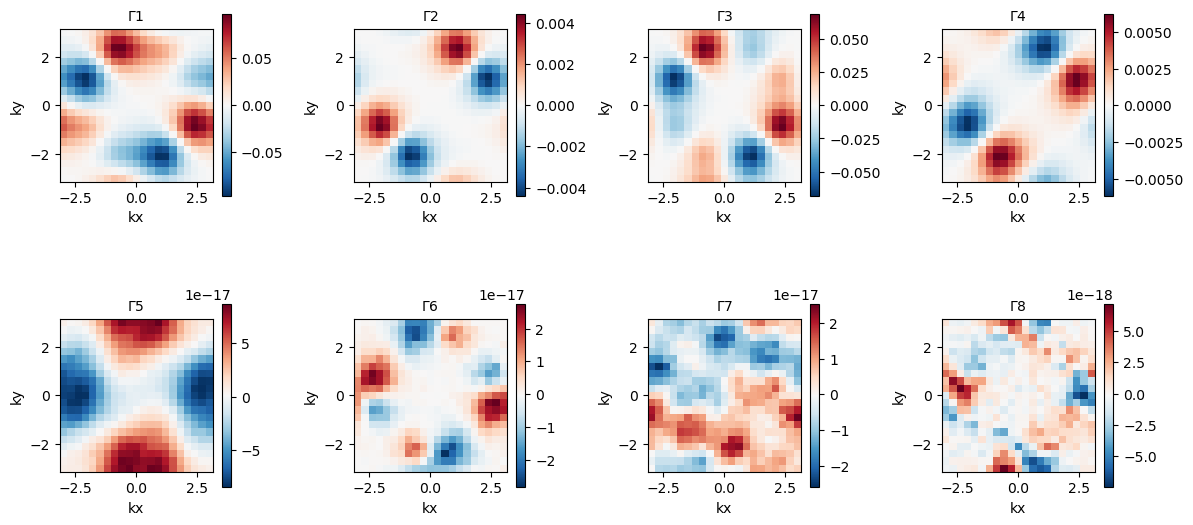

In [130]:
# =========================
# PLOT ALL CHANNELS (2x4)
# =========================
fig, axes = plt.subplots(Nc//4, 4, figsize=(12, 6))  # 2 rows, 4 cols

axes = axes.flatten()  # make indexing easy

for i in range(Nc):

    Z = (Delta_all[0,:, i]).real.reshape(Nk, Nk)
    
    #Z = Delta[:, i].imag.reshape(Nk, Nk)

    vmax = np.max(Z)  # symmetric color scale
    vmin = np.min(Z)

    im = axes[i].imshow(Z,
                        origin='lower',
                        extent=[-np.pi, np.pi, -np.pi, np.pi],
                        cmap='RdBu_r',
                        vmin=vmin, vmax=vmax)

    axes[i].set_title(r"$\Gamma$"+str(i+1), fontsize=10)
    axes[i].set_xlabel("kx")
    axes[i].set_ylabel("ky")

    # individual colorbar (optional)
    fig.colorbar(im, ax=axes[i], shrink=0.7)

plt.tight_layout()
plt.show()

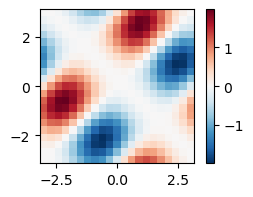

In [128]:
# old Hamiltonian
#Z = np.cos(kx/2) * np.cos(ky/2) # s-wave
#Z = np.sin(kx/2) * np.sin(ky/2) # d-wave
#Z = np.sin(kx/2) * np.cos(ky/2) # px-wave
#Z = np.sin(ky/2) * np.cos(kx/2) # py-wave
#Z = np.sin(kx) * (1-np.cos(ky)) # f1
#Z = np.sin(ky) * (1-np.cos(kx)) # f2

#Z_flat = np.cos(k_points[:,0]) + np.cos(k_points[:,1]) # s-wave kx=kp, ky=km
#Z_flat = np.cos(k_points[:,0]) - np.cos(k_points[:,1]) # d-wave kx=kp, ky=km
#Z_flat = np.sin(k_points[:,0]) + np.sin(k_points[:,1]) # px-wave kx=kp, ky=km
#Z_flat = np.sin(k_points[:,0]) - np.sin(k_points[:,1]) # py-wave kx=kp, ky=km

#Z_flat = np.sin(k_points[:,0] + k_points[:,1]) * (1 - np.cos(k_points[:,0] - k_points[:,1])) # f1 kx=kp, ky=km
Z_flat = np.sin(k_points[:,0] - k_points[:,1]) * (1 - np.cos(k_points[:,0] + k_points[:,1])) # f2 kx=kp, ky=km


# reshape to 2D grid
Z = Z_flat.reshape(Nk, Nk)

plt.figure(figsize=(3,2))

plt.imshow(Z,
           origin='lower',
           extent=[-np.pi,np.pi,-np.pi,np.pi],
           cmap='RdBu_r')

plt.colorbar()
#plt.title()
plt.show()